## algorithm design and anlysis-2026 spring  homework 1 
**Deadline**：2026.5.20

**name**:


note：
---
1. 带有\*的题目，申请免上课的同学，必须完成，其他同学选作；
2. 请独立完成，如求助了他人或者大模型，请著明，并且不可省略算法分析部分；
4. 如若作答有雷同，全部取消成绩；
3. 需要书面作答的题目，可以通过引用图片的形式添加，但是注意上传项目时包含所引用的图片的源文件；
4. $log_n$ 默认表示$log_2{n}$;

## 问题 1

根据下列递归公式, 计算下列 $T(n)$ 对应的的渐近上界。要求所求的边界尽可能的紧（tight）, 请写明步骤。

1. $T(1)=1; T(n)=T(n/4)+1$ for $n>1$
2. $T(1)=1;T(n)=3T(n/3)+n^2$ for $n>1$
3. $T(1)=1;T(n)=T(2n/3)+1$ for $n>1$
4. $T(1)=1;T(n)=5T(n/4)+n$ for $n>1$
5. $T(n)=1 \ for\ n \le 2 ; T(n)=T(\sqrt{n})+1 \ for \ n>2$

idea: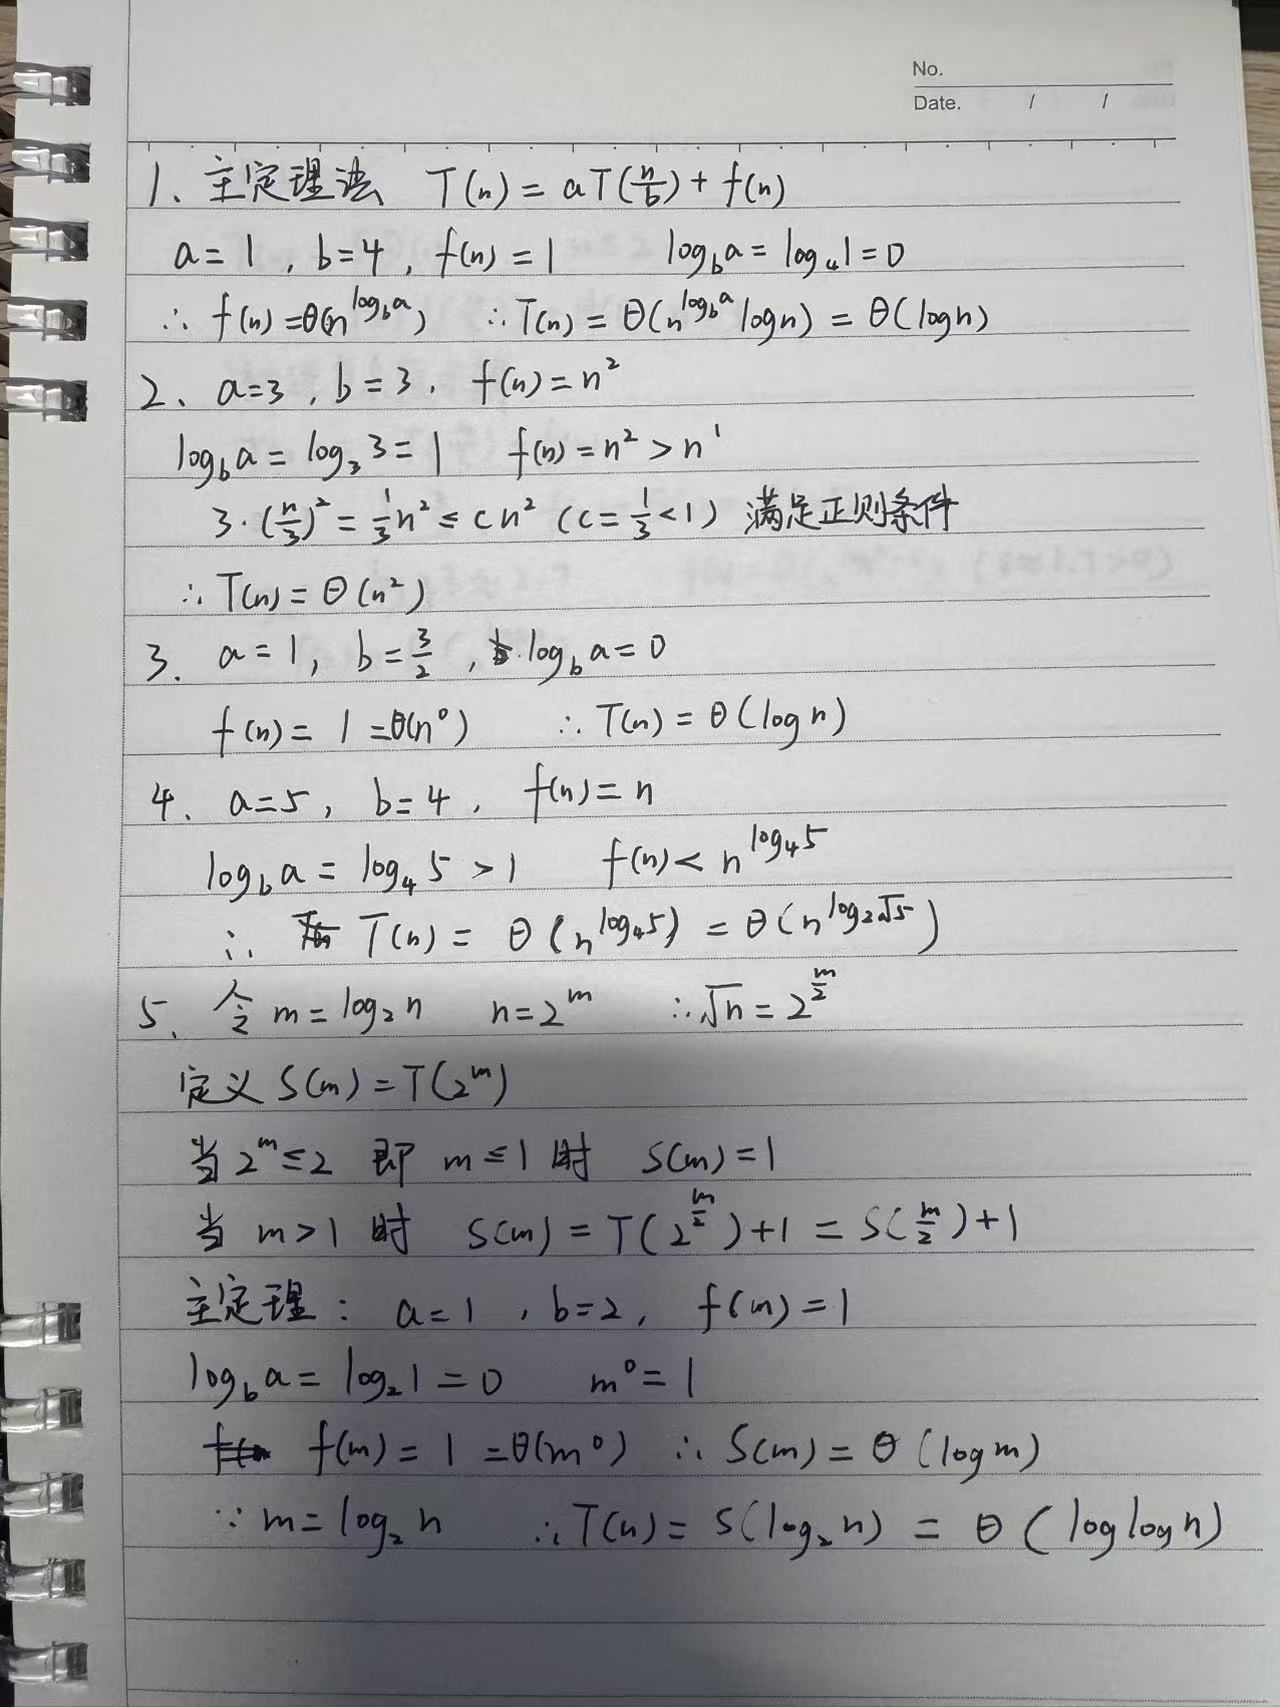

## 问题 2

观察下方的分治算法（divide-and-conquer algorithm）的伪代码, 回答下面问题

```latex
DoSomething(A,p,r)
-----
n := r-p+1
if n=2 and A[p]>A[r] then
    swap A[p] and A[r]
else if n >= 3 then
    m = ceil(2n/3)
    DoSomething(A,p,p+m-1)
    DoSomething(A,r-m+1,r)
    DoSomething(A,p,p+m-1)  
    
---
first call: DoSomething(A,1,n)
```

note：$ceil(2n/3)=\left\lceil {2n/3} \right\rceil$；$:=$ 表示赋值, 等价于 $\to$；A是一个包含n的整数元素的数组, 

1. 写出该算法时间复杂度的递归公式, 并求解其对应的渐进表示
2. 描述一下该算法的功能, 并判断是否是最高效的解决方案
3. \* 使用python编程实现上述算法或其对应的更高效版本的算法

idea:1.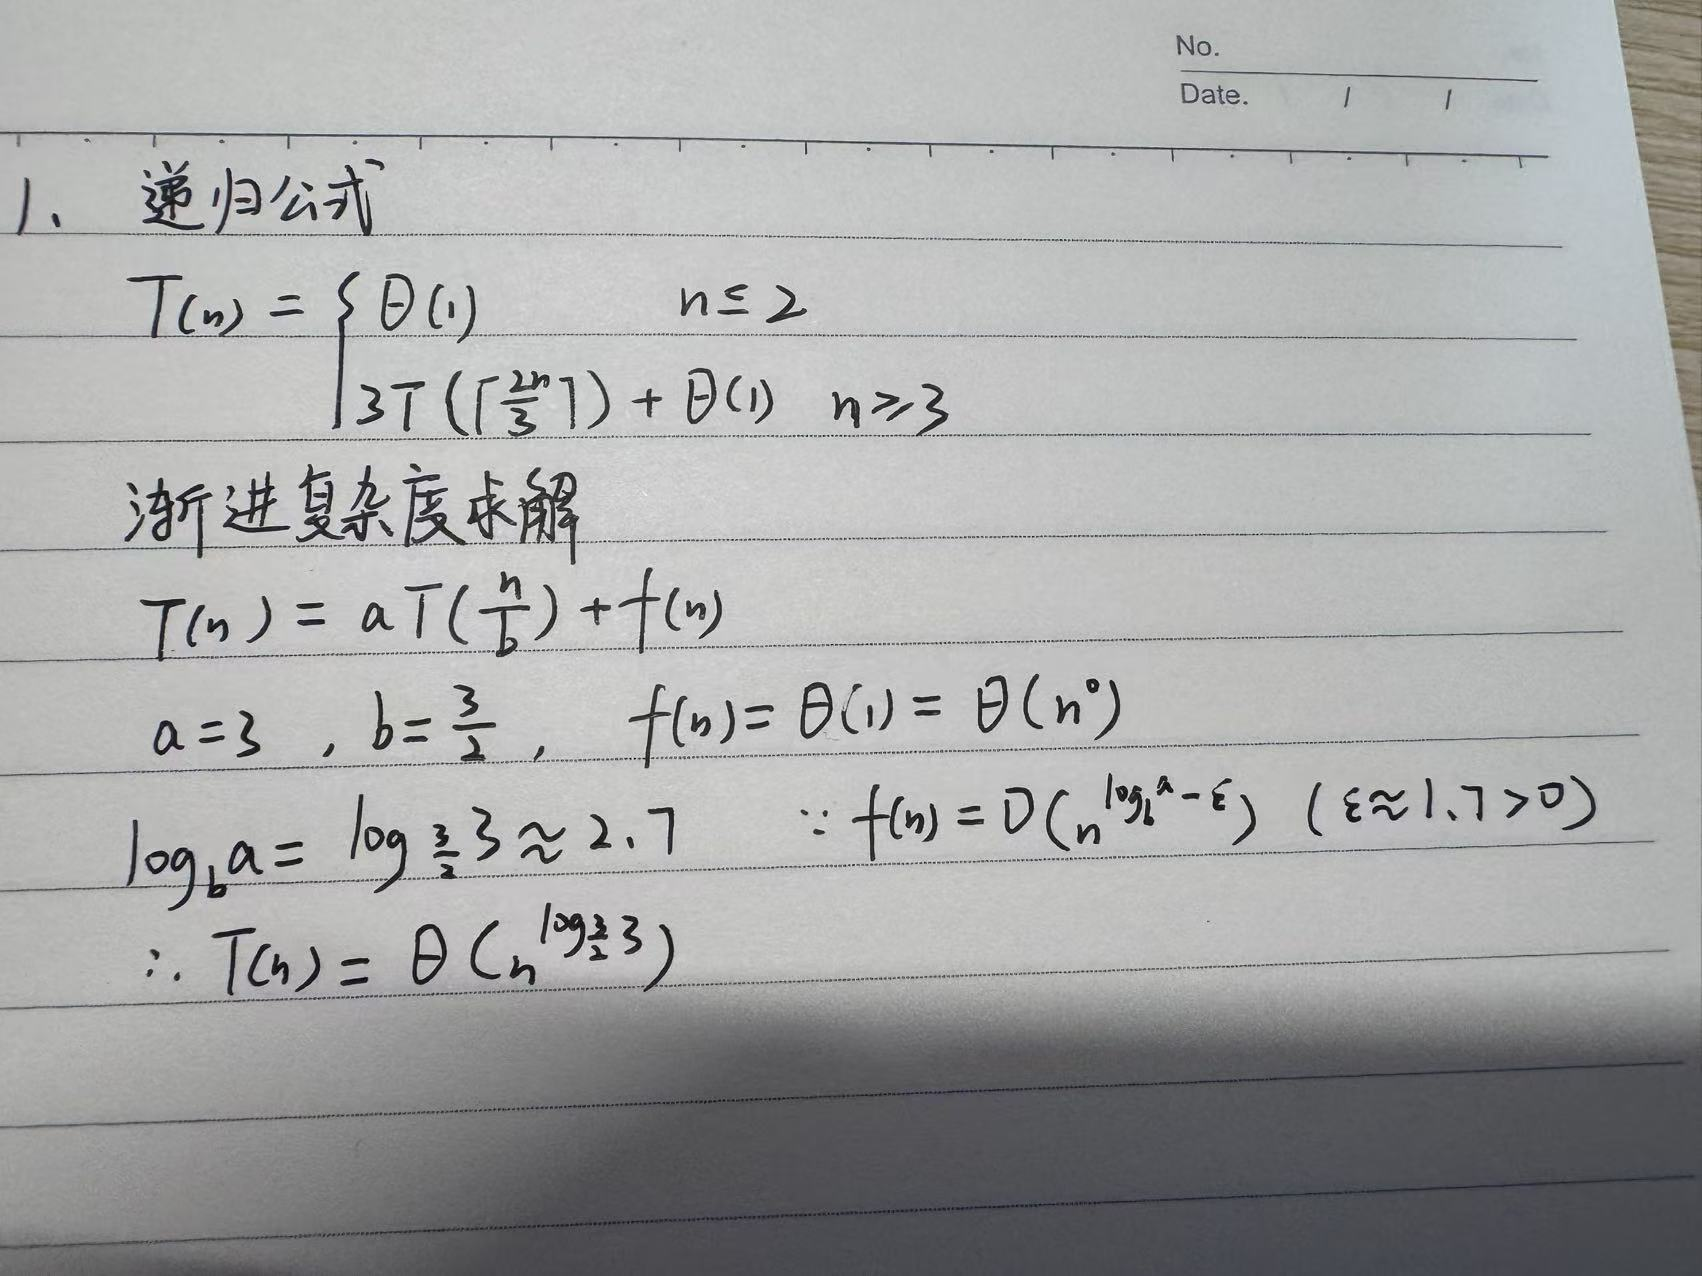
2.功能描述：
该算法的作用是对数组 A 的指定区间 [p, r] 内的整数元素进行从小到大排序。
是否最高效：
不是最高效的解决方案，该算法的时间复杂度约为 Θ(n^{2.7})，在相同数据规模下，它的运行速度甚至比普通的冒泡排序 O(n^2) 还要慢。

In [3]:
# add your code here
#3.
def stooge_sort(arr, p=0, r=None):
  
    if r is None:
        r = len(arr) - 1
    n = r - p + 1
    
    # 基本情况：长度为2时交换逆序对
    if n == 2 and arr[p] > arr[r]:
        arr[p], arr[r] = arr[r], arr[p]
    # 递归情况：长度>=3时三次递归
    elif n >= 3:
        m = (2 * n + 2) // 3
        stooge_sort(arr, p, p + m - 1)
        stooge_sort(arr, r - m + 1, r) 
        stooge_sort(arr, p, p + m - 1) 
    
    return arr

if __name__ == "__main__":
    test_array = [5, 3, 8, 4, 2, 7, 1, 6]
    print("原始数组:", test_array)
    stooge_sort(test_array)
    print("Stooge排序后:", test_array)
# your algorithm time complexity is:
#Θ(n^{2.7})
#使用大模型辅助

原始数组: [5, 3, 8, 4, 2, 7, 1, 6]
Stooge排序后: [1, 2, 3, 4, 5, 6, 7, 8]


## 问题 3

给定一个包含n个元素的数组 `profits` , 它的第 `i` 个元素 `profits[i]` 表示一支股票第 `i` 天的**收益**（正数表示涨, 负数表示跌）。你只能选择 **某一天** 买入这只股票, 并选择在 **未来的某一个不同的日子** 卖出该股票。

1. 设计一个算法来计算你所能获取的最大利润和对应买入和卖出的日期。请分析算法方案, 计算其时间复杂度, 并且使用python编程实现该算法。

2. \* 设计一个时间复杂度为 $O(n)$的算法实现该算法

e.g. :
---
profits=[3,2,1,-7,5,2,-1,3,-1], 第5天买入, 第8天卖出, 收益最大：9

idea:1.算法方案：枚举所有可能的买入日期（对应数组起始索引i）和卖出日期（对应数组结束索引j，j > i），计算每对日期的利润，记录最大值及对应日期。
时间复杂度：O(n²)

In [7]:
#1.
def max_profit_brute_force(profits):
    n = len(profits)
    if n < 2:
        return 0, 0, 0  # 无法完成交易，利润为0
    
    max_profit = float('-inf')
    buy_day = 0
    sell_day = 0
    
    for i in range(n - 1):
        current_profit = profits[i]
        for j in range(i + 1, n):
            current_profit += profits[j]
            if current_profit > max_profit:
                max_profit = current_profit
                buy_day = i + 1    # 数组索引转日期（+1）
                sell_day = j + 1
    
    return max_profit, buy_day, sell_day
if __name__ == "__main__":
    profits = [3, 2, 1, -7, 5, 2, -1, 3, -1]
    profit, buy, sell = max_profit_brute_force(profits)
    print(f"最大利润：{profit}，买入日期：第{buy}天，卖出日期：第{sell}天")

最大利润：9，买入日期：第5天，卖出日期：第8天


idea:2.算法方案：枚基于动态规划思想，维护两个核心变量：
current_max：以当前元素结尾的、长度至少为 2 的最大子数组和
global_max：全局最大子数组和
同时维护子数组的起始索引，用于记录买卖日期。对于每个位置k：
以k结尾的合法子数组有两种可能：
延续前一个合法子数组：current_max + profits[k]
重新开始一个长度为 2 的子数组：profits[k-1] + profits[k]
取两者较大值更新current_max，并同步更新起始索引，若current_max大于global_max，则更新全局最大值及对应日期

In [9]:
# add your code here
def max_profit_kadane(profits):
    n = len(profits)
    if n < 2:
        return 0, 0, 0 
    
    current_max = profits[0] + profits[1]
    current_start = 0
    global_max = current_max
    global_start = current_start
    global_end = 1
    
    # 从索引2开始遍历
    for k in range(2, n):
        option1 = current_max + profits[k]   
        option2 = profits[k-1] + profits[k]      
        
        if option1 > option2:
            current_max = option1
        else:
            current_max = option2
            current_start = k - 1
        
        if current_max > global_max:
            global_max = current_max
            global_start = current_start
            global_end = k
    
    buy_day = global_start + 1
    sell_day = global_end + 1
    return global_max, buy_day, sell_day
if __name__ == "__main__":
    profits = [3, 2, 1, -7, 5, 2, -1, 3, -1]
    profit, buy, sell = max_profit_kadane(profits)
    print(f"最大利润：{profit}，买入日期：第{buy}天，卖出日期：第{sell}天")
# your algorithm time complexity is:
#O(n)
#使用大模型辅助

最大利润：9，买入日期：第5天，卖出日期：第8天


## 问题 4

给定一个包含不同整数元素的数组 $ A[1..n]$ ,并且满足条件：$A[1]>A[2]$ 并且 $A[n-1]<A[n]$; 规定：如果一个元素比它两边的邻居元素都小, 即：$A[x]<A[x-1], A[x]<A[x+1]$ , 称这个元素A[x]为“局部最小”。通过遍历一次数组, 我们可以很容易在 $O(n)$的时间复杂度下找到一个局部最小值, 


1. 分析该问题, 设计一个算法在$O(logn)$的时间复杂度下找到一个局部最小(返回数值), 要求：分析算法设计思路, 并且使用python编程实现
2. \* 设计算法找出所有局部最小值, 分析算法设计思路, 并使用python编程实现

e.g.:
---
A=[9, 3, 7, 2, 1, 4, 5 ] 时,  局部最小元素为 3, 1

idea:1.采用二分查找思想，每次取当前搜索区间的中间位置，若该位置元素同时小于左右邻居则直接返回，否则根据中间元素与相邻元素的大小关系，选择仍满足 “左降右升” 条件的左半或右半区间继续搜索，通过每次将搜索范围减半实现 O (logn) 的时间复杂度。

In [19]:
# add your code here
#1.
def find_one_local_min(A):
    if len(A) < 3:
        raise ValueError("数组长度必须至少为3")
    if A[0] <= A[1]:
        raise ValueError("数组第一个元素必须大于第二个元素")
    if A[-2] >= A[-1]:
        raise ValueError("数组倒数第二个元素必须小于最后一个元素")
    
    left = 0
    right = len(A) - 1
    
    while left <= right:
        mid = (left + right) // 2
        if 1 <= mid <= len(A) - 2:
            if A[mid] < A[mid-1] and A[mid] < A[mid+1]:
                return A[mid]
        # 决策搜索方向
        if mid > 0 and A[mid] > A[mid-1]:
            right = mid - 1 
        else:
            left = mid + 1  
    
    
    raise RuntimeError("未找到局部最小值（输入可能不符合要求）")


if __name__ == "__main__":
    test_array = [9, 3, 7, 2, 1, 4, 5]
    print("找到的一个局部最小值:", find_one_local_min(test_array))  
# your algorithm time complexity is:
#O (logn)

找到的一个局部最小值: 1


idea:2.由于局部最小值可能分布在数组任意中间位置，无法通过二分法批量定位，因此采用线性遍历法，仅遍历数组中除首尾元素外的所有中间元素，逐个判断其是否同时小于左右两个邻居，将满足条件的元素收集起来即为所有局部最小值，时间复杂度为 O (n)。

In [20]:
# add your code here
def find_all_local_mins(A):
    if len(A) < 3:
        raise ValueError("数组长度必须至少为3")
    if A[0] <= A[1]:
        raise ValueError("数组第一个元素必须大于第二个元素")
    if A[-2] >= A[-1]:
        raise ValueError("数组倒数第二个元素必须小于最后一个元素")
    
    local_mins = []
    # 遍历所有可能的局部最小值位置
    for i in range(1, len(A) - 1):
        if A[i] < A[i-1] and A[i] < A[i+1]:
            local_mins.append(A[i])
    return local_mins


if __name__ == "__main__":
    test_array = [9, 3, 7, 2, 1, 4, 5]
    print("所有局部最小值:", find_all_local_mins(test_array))  
# your algorithm time complexity is:
#O (n)
#使用大模型辅助

所有局部最小值: [3, 1]


## 问题 5

给定包含n个不同数字的一组数, 寻找一种基于比较的算法在这组数中找到k个最小的数字, 并按顺序输出它们。

1. 将n个数先进行排序, 然后按顺序输出最小的k个数。要求：选择合适的排序算法实现上述操作, 计算算法时间复杂度, 并使用python编程实现。
2. 建立一个包含这n个数的堆（heap）, 并且调用 k 次Extract-min 按顺序输出最小的k个数。使用往空堆中不断插入元素的方法建立堆, 分析这种方法建堆的时间复杂度, 并使用python编程实现
3. \* 假设数组中包含的数据总数目超过了计算机的存储能力, 请设计一个算法, 找到这堆数据的前k小的数值, 计算时间复杂度, 并使用python实现该算法, 假设计算机一定能存储k个数据。

e.g.：
---
数组arr=[5,4,3,2,6,1,88,33,22,107] 的前3个最小数据为：1, 2, 3

idea:1.选择基于比较的高效排序算法（如 Python 内置的 Timsort）对整个数组进行排序，排序阶段的时间复杂度为 O (nlogn)，之后截取前 k 个元素并输出的时间复杂度为 O(k)，因此整体时间复杂度为 O(nlogn)

In [21]:
# add your code here
def find_k_smallest_sort(arr, k):
    arr_sorted = sorted(arr)
    return arr_sorted[:k]

# 测试
if __name__ == "__main__":
    arr = [5,4,3,2,6,1,88,33,22,107]
    k = 3
    print(find_k_smallest_sort(arr, k)) 
# your algorithm time complexity is:
#O(nlogn)

[1, 2, 3]


idea:2.采用逐个插入元素的方式构建小根堆，每个元素插入时需调整堆结构，时间复杂度为 O (logi)（i 为当前堆的大小），建堆总时间复杂度为 O (n logn)；每次提取堆顶最小元素后需重新调整堆，时间复杂度为 O (logn)，执行 k 次的时间复杂度为 O (klogn)，因此整体时间复杂度为 O (nlogn)

In [22]:
# add your code here
import heapq

def find_k_smallest_heap_insert(arr, k):
    heap = []
    for num in arr:
        heapq.heappush(heap, num)
    result = []
    for _ in range(k):
        result.append(heapq.heappop(heap))
    return result

# 测试
if __name__ == "__main__":
    arr = [5,4,3,2,6,1,88,33,22,107]
    k = 3
    print(find_k_smallest_heap_insert(arr, k))
# your algorithm time complexity is:
#O (nlogn)

[1, 2, 3]


idea:3.维护一个大小为 k 的大根堆，遍历所有数据元素，若堆的大小小于 k 则直接插入堆；若当前元素小于堆顶元素，则弹出堆顶并插入当前元素。每个元素最多执行一次堆的插入和删除操作，每次操作的时间复杂度为 O (logk)，因此整体时间复杂度为 O (nlogk)

In [23]:
# add your code here
import heapq

def find_k_smallest_large_data(data_iterator, k):
    max_heap = []
    for num in data_iterator:
        if len(max_heap) < k:
            heapq.heappush(max_heap, -num)
        elif num < -max_heap[0]:
            heapq.heappop(max_heap)
            heapq.heappush(max_heap, -num)
    result = [-x for x in max_heap]
    result.sort()
    return result

# 测试
if __name__ == "__main__":
    arr = [5,4,3,2,6,1,88,33,22,107]
    k = 3
    data_iter = iter(arr)
    print(find_k_smallest_large_data(data_iter, k)) 
# your algorithm time complexity is:
#O (nlogk)

[1, 2, 3]


## 问题 6

> 星球碰撞问题：现有n个星球，在同一条直线上运行，如数组A所示，元素的绝对值表示星球的质量，负数表示星球自右向左运动，正数表示星球自左向右运动，当两个星球相撞的时候，质量小的会消失，大的保持不变，**质量相同的两个星球碰撞后自右向左运动的星球消失，自左向右的星球保持不变**，假设所有星球的速度大小相同。
>
> $ A=[23,-8, 9, -3, -7, 9, -23, 22] $

请设计一个算法模拟星球的运行情况，输出最终的星球存续情况（输出一个数组），分析算法设计思路，计算时间复杂度，并基于python编程实现。

e.g.
---
1.  输入： A=[-3,-6,2,8, 5,-8,9,-2,1]， 输出：[-3, -6, 2, 8, 9, 1]

2. 输入：A=[23,-8, 9, -3, -7, 9, -23, 22], 输出：[23, 22]

idea:采用栈结构模拟星球碰撞过程，遍历数组中的每个星球，对于当前星球，持续检查栈顶元素是否满足碰撞条件（栈顶为正且当前星球为负），若满足则根据质量大小处理碰撞：栈顶质量更小时弹出栈顶继续检查，质量相等时当前星球消失且栈顶保留，栈顶质量更大时当前星球消失；若不满足碰撞条件则将当前星球压入栈，由于每个星球最多入栈和出栈一次，因此时间复杂度为 O (n)

In [24]:
# add your code here
def planet_collision(A):
    stack = []
    for num in A:
        while stack and stack[-1] > 0 and num < 0:
            top = stack[-1]
            if abs(top) < abs(num):
                stack.pop()
            elif abs(top) == abs(num):
                num = None
                break
            else:
                num = None
                break
        if num is not None:
            stack.append(num)
    return stack

# 测试示例
if __name__ == "__main__":
    A1 = [-3, -6, 2, 8, 5, -8, 9, -2, 1]
    print(planet_collision(A1))  
    
    A2 = [23, -8, 9, -3, -7, 9, -23, 22]
    print(planet_collision(A2))  
# your algorithm time complexity is:
# O (n)

[-3, -6, 2, 8, 9, 1]
[23, 22]


## 问题 7

> 0-1背包问题：现在有4块大理石，每个大理石对应的重量和价值使用一个元组表示, 即（重量，价值），4块大理石的重量和价值为：[(5,10), (4,40), (6,30), (3, 50)], 假设你有一辆最大承重为9的小推车，请问使用这个小推车装大理石的最大价值为多少

请设计一个算法解决该问题，分析算法设计思路，计算时间复杂度，并基于python编程实现

idea:本题采用一维动态规划优化解决，定义 dp [j] 表示承重为 j 的背包能装载的最大价值，初始化长度为最大承重 + 1 的全 0 数组，遍历每个大理石物品时从后往前遍历背包容量（避免重复选取同一物品），若当前容量可容纳该物品则更新 dp [j] 为不选该物品的价值与选该物品的价值中的较大值，最终 dp [max_weight] 即为最大价值，时间复杂度为 O (nC)(n 为物品数量，C 为背包最大承重）

In [25]:
# add your code here
def knapsack(items, max_weight):
    dp = [0] * (max_weight + 1)
    for w, v in items:
        for j in range(max_weight, w - 1, -1):
            dp[j] = max(dp[j], dp[j - w] + v)
    return dp[max_weight]

if __name__ == "__main__":
    marbles = [(5, 10), (4, 40), (6, 30), (3, 50)]
    max_capacity = 9
    print(knapsack(marbles, max_capacity))
# your algorithm time complexity is:
#O (nC)

90


## 问题 8

给你二叉搜索树的根节点 root ，该树中的恰好两个节点的值被错误地交换。请在不改变其结构的情况下，恢复这棵树 。设计算法解决该问题，分析算法设计思路，计算时间复杂度，并基于python编程实现

e.g.:
---
1.

<div style="text-align:center;width:200px;"> <img alt="" src="./fig/hw3q9-1.jpg"> </div>
输入：root = [1,3,null,null,2]， 输出为：[3,1,null,null,2]， 

解释：3 不能是 1 的左孩子，因为 3 > 1 。交换 1 和 3 使二叉搜索树有效。

2.

 <div style="text-align:center;width:200px;"> <img alt="" src="./fig/hw3q9-1.jpg"> </div>
输入： root=[3,1,4,null,null,2]， 输出为：[2,1,4,null,null,3]

解释：2 不能在 3 的右子树中，因为 2 < 3 。交换 2 和 3 使二叉搜索树有效。

idea:利用二叉搜索树中序遍历为严格递增序列的核心性质，通过中序遍历定位两个被错误交换的节点。遍历过程中记录前一个访问节点，当出现前节点值大于当前节点值时，第一个此类前节点即为第一个错误节点，最后一个此类当前节点即为第二个错误节点，最终交换两节点值即可恢复树结构。时间复杂为O(n)

In [26]:
# add your code here
class TreeNode:
    def __init__(self, val=0, left=None, right=None):
        self.val = val
        self.left = left
        self.right = right

def recoverTree(root):
    first = second = prev = NoneC
    def inorder(node):
        nonlocal first, second, prev
        if not node:
            return
        inorder(node.left)
        if prev and prev.val > node.val:
            if not first:
                first = prev
            second = node
        prev = node
        inorder(node.right)
    inorder(root)
    first.val, second.val = second.val, first.val


def buildTree(nodes):
    if not nodes:
        return None
    root = TreeNode(nodes[0])
    queue = [root]
    i = 1
    while queue and i < len(nodes):
        current = queue.pop(0)
        if nodes[i] is not None:
            current.left = TreeNode(nodes[i])
            queue.append(current.left)
        i += 1
        if i < len(nodes) and nodes[i] is not None:
            current.right = TreeNode(nodes[i])
            queue.append(current.right)
        i += 1
    return root


def inorderTraversal(root):
    res = []
    def inorder(node):
        if not node:
            return
        inorder(node.left)
        res.append(node.val)
        inorder(node.right)
    inorder(root)
    return res

# 测试
if __name__ == "__main__":
    # 示例1
    root1 = buildTree([1, 3, None, None, 2])
    recoverTree(root1)
    print("示例1恢复后中序遍历:", inorderTraversal(root1))
    
    # 示例2
    root2 = buildTree([3, 1, 4, None, None, 2])
    recoverTree(root2)
    print("示例2恢复后中序遍历:", inorderTraversal(root2)) 
# your algorithm time complexity is:
#O(n)
#使用大模型辅助

示例1恢复后中序遍历: [1, 2, 3]
示例2恢复后中序遍历: [1, 2, 3, 4]


## 问题 9 \*
给定 `n` 个非负整数表示每个宽度为 `1` 的柱子的高度图，计算按此排列的柱子，下雨之后能接多少雨水。



<div style="text-align:center;width:800px;"> <img alt="" src="./fig/hw3q6.png"> </div>

请分析算法设计思路，计算时间复杂度，并基于python编程实现

idea:采用双指针法最优求解，每个位置能接的雨水量等于其左右两侧最大高度的较小值减去当前高度。用左右指针从两端向中间遍历，维护左右两侧的最大高度left_max和right_max。若left_max < right_max，则左指针位置的雨水由left_max决定（右侧存在更高边界），反之右指针位置由right_max决定，一次遍历即可累加总雨水量。时间复杂度为O(n)

In [27]:
# add your code here
def trap(height):
    left, right = 0, len(height) - 1
    left_max = right_max = res = 0
    while left < right:
        if height[left] < height[right]:
            if height[left] >= left_max:
                left_max = height[left]
            else:
                res += left_max - height[left]
            left += 1
        else:
            if height[right] >= right_max:
                right_max = height[right]
            else:
                res += right_max - height[right]
            right -= 1
    return res

if __name__ == "__main__":
    print(trap([0,1,0,2,1,0,1,3,2,1,2,1])) 
    print(trap([4,2,0,3,2,5]))             
# your algorithm time complexity is:
#O(n)
#使用大模型辅助

6
9


## 问题 10

给你一个二叉树的根节点 root ，树中每个节点都存放有一个 0 到 9 之间的数字。每条从根节点到叶节点的路径都代表一个数字：

> 例如，从根节点到叶节点的路径 1 -> 2 -> 3 表示数字 123 。

设计一个算法计算从根节点到叶节点生成的所有数字之和 ，分析算法设计思路，计算时间复杂度，并基于python编程实现

叶节点:是指没有子节点的节点。

e.g.:
---
1.

 <div style="text-align:center;width:200px;"> <img alt="figure" src="./fig/hw3q10-1.jpg"> </div>

 输入：root = [1,2,3], 输出：25

解释：从根到叶子节点路径 1->2 代表数字 12，1->3 代表数字 13，因此和为 12 + 13 = 25 。

2.

 <div style="text-align:center;width:200px;"> <img alt="figure" src="./fig/hw3q10-2.jpg"> </div>

 输入：root = [4,9,0,5,1], 输出：1026

解释：从根到叶子节点路径 4->9->5 代表数字 495，4->9->1 代表数字 491，4->0 代表数字 40。因此和为 495 + 491 + 40 = 1026 。

idea采用深度优先搜索（DFS）递归遍历二叉树，维护从根节点到当前节点的路径数字。每访问一个节点，将当前路径数字更新为当前数字*10 + 节点值；当到达叶子节点时返回该路径数字；非叶子节点则递归计算左右子树的路径和并累加，最终得到所有根到叶子路径的数字总和。时间复杂度为O(n)

In [28]:
# add your code here
class TreeNode:
    def __init__(self, val=0, left=None, right=None):
        self.val = val
        self.left = left
        self.right = right

def sumNumbers(root):
    def dfs(node, cur):
        if not node:
            return 0
        cur = cur * 10 + node.val
        if not node.left and not node.right:
            return cur
        return dfs(node.left, cur) + dfs(node.right, cur)
    return dfs(root, 0)

def buildTree(nodes):
    if not nodes:
        return None
    root = TreeNode(nodes[0])
    queue = [root]
    i = 1
    while queue and i < len(nodes):
        current = queue.pop(0)
        if nodes[i] is not None:
            current.left = TreeNode(nodes[i])
            queue.append(current.left)
        i += 1
        if i < len(nodes) and nodes[i] is not None:
            current.right = TreeNode(nodes[i])
            queue.append(current.right)
        i += 1
    return root

if __name__ == "__main__":
    root1 = buildTree([1,2,3])
    print(sumNumbers(root1))
    root2 = buildTree([4,9,0,5,1])
    print(sumNumbers(root2))  
# your algorithm time complexity is:
#O(n)
#使用大模型辅助

25
1026
